In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
def generate_mandelbrot_naive(width, height, max_iter):
    # Define region: x in [-2, 1], y in [-1.5, 1.5]
    xmin, xmax = -2.0, 1.0
    ymin, ymax = -1.5, 1.5
    
    # Create grid of complex numbers c over this region
    # Generate width evenly spaced x-values and height evenly spaced y-values
    x_vals = np.linspace(xmin, xmax, width)
    y_vals = np.linspace(ymin, ymax, height)
    
    # Return 2D array of iteration counts
    # Initialize the array to hold our results
    iterations = np.zeros((height, width))
    
    # For each point c in grid
    for i, y in enumerate(y_vals):
        for j, x in enumerate(x_vals):
            # Form complex numbers: c = x + iy for each grid point 
            c = complex(x, y)
            
            # Initialize z_0 = 0
            z = 0.0 + 0.0j
            
            # For n = 0 to max_iter:
            for n in range(max_iter):
                # Compute z_{n+1} = z_n^2 + c
                z = z**2 + c
                
                # If |z_{n+1}| > 2 Point escapes
                # Threshold |z| > 2 guarantees divergence
                if abs(z) > 2.0:
                    iterations[i, j] = n # Store n
                    break
            else:
                # If loop completes: Point is in set, store max_iter
                iterations[i, j] = max_iter
                
    return iterations

In [17]:
# Typical: max_iter = 100, resolution: 1024x1024 
width, height = 1024, 1024
max_iter = 100

In [18]:
print("Calculating Mandelbrot set (Naive)....")
mandelbrot_image = generate_mandelbrot_naive(width, height, max_iter)

Calculating Mandelbrot set (Naive)....


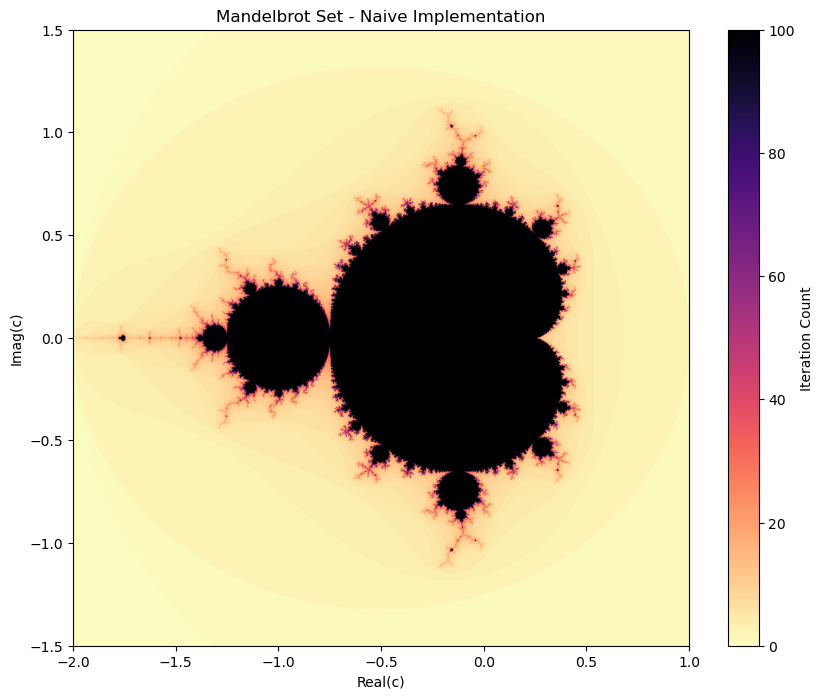

In [19]:
# Visualize with colormap
plt.figure(figsize=(10, 8))
# Using 'magma' gives a great visual representation
plt.imshow(mandelbrot_image, cmap='magma_r', extent=[-2.0, 1.0, -1.5, 1.5]) 
plt.colorbar(label='Iteration Count')
plt.title("Mandelbrot Set - Naive Implementation")
plt.xlabel("Real(c)")
plt.ylabel("Imag(c)")
plt.show()

Highest number, gets the maximum brightness here. the black part in center represents that the points were inside the unit 2, modulus. 

## NumPy Vectorized Implementation


In [20]:
def generate_mandelbrot_numpy(width, height, max_iter):
    # Define region: x in [-2, 1] and y in [-1.5, 1.5]
    xmin, xmax = -2.0, 1.0
    ymin, ymax = -1.5, 1.5

    # Build the full complex grid in one shot
    x_vals = np.linspace(xmin, xmax, width)
    y_vals = np.linspace(ymin, ymax, height)
    X, Y = np.meshgrid(x_vals, y_vals)
    C = X + 1j * Y                        # complex c for every pixel

    Z = np.zeros_like(C)                             # z_0 = 0 for all points
    iterations = np.full((height, width), max_iter)  # defaultt
    not_escaped = np.ones((height, width), dtype=bool)

    for n in range(max_iter):
        # Apply to points that haven't escaped yet
        Z[not_escaped] = Z[not_escaped] ** 2 + C[not_escaped]

        # Detect newly escaped points (|z| > 2)
        newly_escaped = not_escaped & (np.abs(Z) > 2.0)
        iterations[newly_escaped] = n   # record escape iteration

        # Remove newly escaped points
        not_escaped[newly_escaped] = False

        # Early exit
        if not not_escaped.any():
            break

    return iterations


In [21]:
print("Calculating Mandelbrot set (NumPy vectorized)....")
mandelbrot_numpy = generate_mandelbrot_numpy(width, height, max_iter)


Calculating Mandelbrot set (NumPy vectorized)....


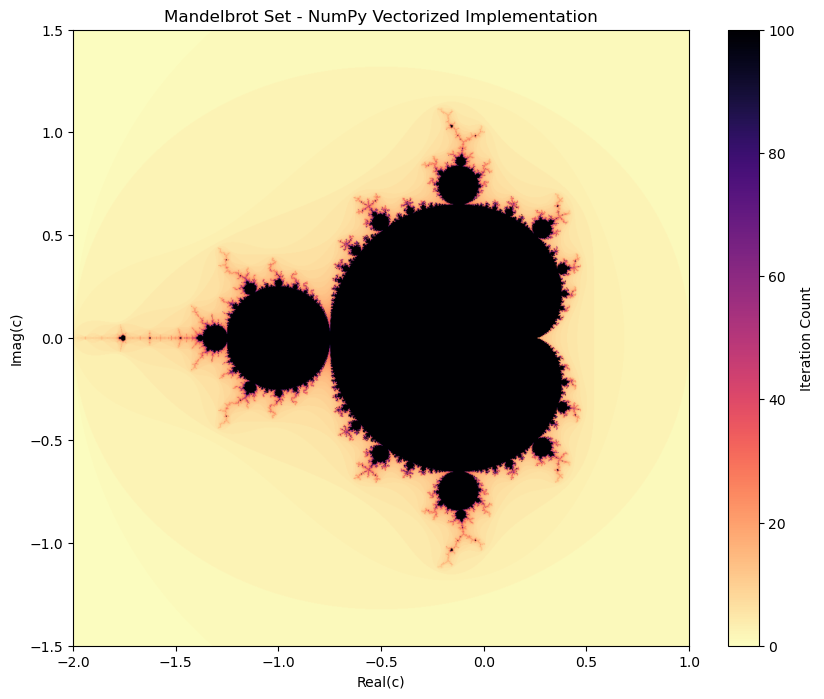

In [22]:
# Visualize the NumPy vectorized result
plt.figure(figsize=(10, 8))
plt.imshow(mandelbrot_numpy, cmap='magma_r', extent=[-2.0, 1.0, -1.5, 1.5])
plt.colorbar(label='Iteration Count')
plt.title("Mandelbrot Set - NumPy Vectorized Implementation")
plt.xlabel("Real(c)")
plt.ylabel("Imag(c)")
plt.show()


## Numba JIT-Compiled Implementation



In [23]:
from numba import njit


In [24]:
@njit
def generate_mandelbrot_numba(width, height, max_iter):
    # Define region: x in [-2, 1], y in [-1.5, 1.5]
    xmin, xmax = -2.0, 1.0
    ymin, ymax = -1.5, 1.5

    iterations = np.zeros((height, width))

    for i in range(height):
        for j in range(width):
            # Map pixel indices to complex plane coordinates
            x = xmin + j * (xmax - xmin) / (width - 1)
            y = ymin + i * (ymax - ymin) / (height - 1)
            c = complex(x, y)

            z = 0.0 + 0.0j
            for n in range(max_iter):
                z = z * z + c          # slightly faster than z**2
                if z.real * z.real + z.imag * z.imag > 4.0:  # |z|^2 > 4 avoids sqrt
                    iterations[i, j] = n
                    break
            else:
                iterations[i, j] = max_iter

    return iterations

_ = generate_mandelbrot_numba(8, 8, 10)
print("Numba JIT compiled and ready.")


Numba JIT compiled and ready.


In [25]:
print("Calculating Mandelbrot set (Numba JIT)....")
mandelbrot_numba = generate_mandelbrot_numba(width, height, max_iter)
print("Done.")


Calculating Mandelbrot set (Numba JIT)....
Done.


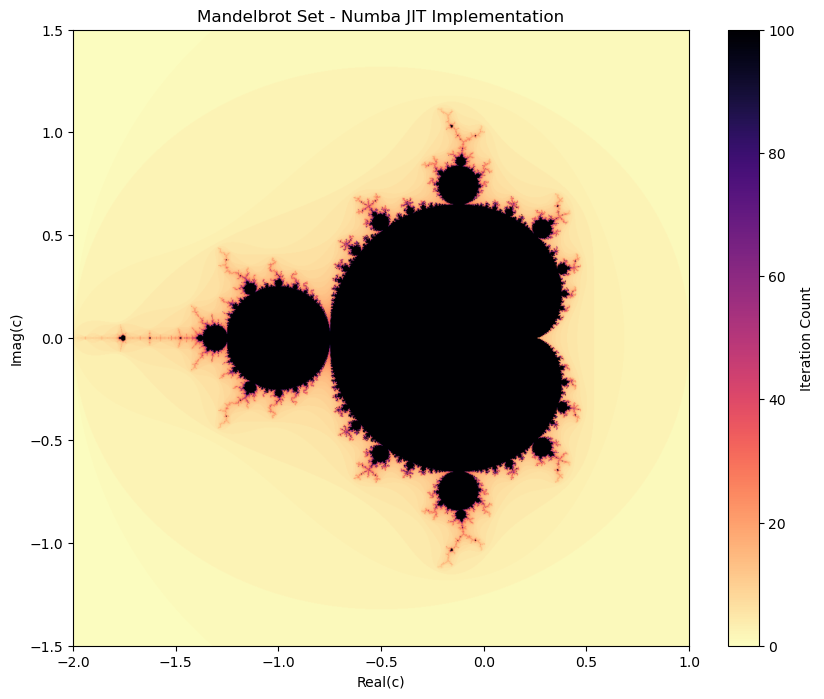

In [26]:
# Visualize the Numba JIT result
plt.figure(figsize=(10, 8))
plt.imshow(mandelbrot_numba, cmap='magma_r', extent=[-2.0, 1.0, -1.5, 1.5])
plt.colorbar(label='Iteration Count')
plt.title("Mandelbrot Set - Numba JIT Implementation")
plt.xlabel("Real(c)")
plt.ylabel("Imag(c)")
plt.show()


## Performance Analysis


In [27]:
import time

# Use consistent parameters for all three versions
width_perf, height_perf = 1024, 1024
max_iter_perf = 100
num_runs = 3  # Run each version multiple times for stable measurements

print("PERFORMANCE ANALYSIS: Mandelbrot Set Implementations")
print(f"Parameters: {width_perf}x{height_perf} resolution, {max_iter_perf} max iterations")
print(f"Each measurement averaged over {num_runs} runs\n")

# NAIVE IMPLEMENTATION TIMING
print("1. NAIVE (Pure Python with nested loops)")
naive_times = []
for run in range(num_runs):
    start = time.perf_counter()
    _ = generate_mandelbrot_naive(width_perf, height_perf, max_iter_perf)
    end = time.perf_counter()
    elapsed = end - start
    naive_times.append(elapsed)
    print(f"   Run {run + 1}: {elapsed:.4f} seconds")

naive_avg = sum(naive_times) / len(naive_times)
print(f"   Average: {naive_avg:.4f} seconds\n")

# NUMPY VECTORIZED IMPLEMENTATION TIMING
print("2. NUMPY VECTORIZED (NumPy operations)")
numpy_times = []
for run in range(num_runs):
    start = time.perf_counter()
    _ = generate_mandelbrot_numpy(width_perf, height_perf, max_iter_perf)
    end = time.perf_counter()
    elapsed = end - start
    numpy_times.append(elapsed)
    print(f"   Run {run + 1}: {elapsed:.4f} seconds")

numpy_avg = sum(numpy_times) / len(numpy_times)
print(f"   Average: {numpy_avg:.4f} seconds\n")

# NUMBA JIT-COMPILED IMPLEMENTATION TIMING
print("3. NUMBA JIT (JIT-compiled to machine code)")
numba_times = []
for run in range(num_runs):
    start = time.perf_counter()
    _ = generate_mandelbrot_numba(width_perf, height_perf, max_iter_perf)
    end = time.perf_counter()
    elapsed = end - start
    numba_times.append(elapsed)
    print(f"   Run {run + 1}: {elapsed:.4f} seconds")

numba_avg = sum(numba_times) / len(numba_times)
print(f"   Average: {numba_avg:.4f} seconds\n")

PERFORMANCE ANALYSIS: Mandelbrot Set Implementations
Parameters: 1024x1024 resolution, 100 max iterations
Each measurement averaged over 3 runs

1. NAIVE (Pure Python with nested loops)
   Run 1: 5.8779 seconds
   Run 2: 5.8784 seconds
   Run 3: 6.0785 seconds
   Average: 5.9449 seconds

2. NUMPY VECTORIZED (NumPy operations)
   Run 1: 2.2574 seconds
   Run 2: 2.3151 seconds
   Run 3: 2.2741 seconds
   Average: 2.2822 seconds

3. NUMBA JIT (JIT-compiled to machine code)
   Run 1: 0.0968 seconds
   Run 2: 0.0971 seconds
   Run 3: 0.0977 seconds
   Average: 0.0972 seconds



In [28]:
# SPEEDUP CALCULATIONS
print("SPEEDUP ANALYSIS (relative to Naive implementation)")

numpy_speedup = naive_avg / numpy_avg
numba_speedup = naive_avg / numba_avg

print(f"NumPy vs Naive:  {numpy_speedup:.2f}x faster")
print(f"Numba vs Naive:  {numba_speedup:.2f}x faster")
print(f"Numba vs NumPy:  {numba_speedup / numpy_speedup:.2f}x faster\n")

# SUMMARY TABLE
print("SUMMARY TABLE")
print(f"{'Implementation':<20} {'Avg Time (s)':<15} {'Speedup':<15}")
print(f"{'Naive':<20} {naive_avg:<15.4f} {'1.00x (baseline)':<15}")
print(f"{'NumPy':<20} {numpy_avg:<15.4f} {f'{numpy_speedup:.2f}x':<15}")
print(f"{'Numba':<20} {numba_avg:<15.4f} {f'{numba_speedup:.2f}x':<15}")


SPEEDUP ANALYSIS (relative to Naive implementation)
NumPy vs Naive:  2.60x faster
Numba vs Naive:  61.17x faster
Numba vs NumPy:  23.48x faster

SUMMARY TABLE
Implementation       Avg Time (s)    Speedup        
Naive                5.9449          1.00x (baseline)
NumPy                2.2822          2.60x          
Numba                0.0972          61.17x         


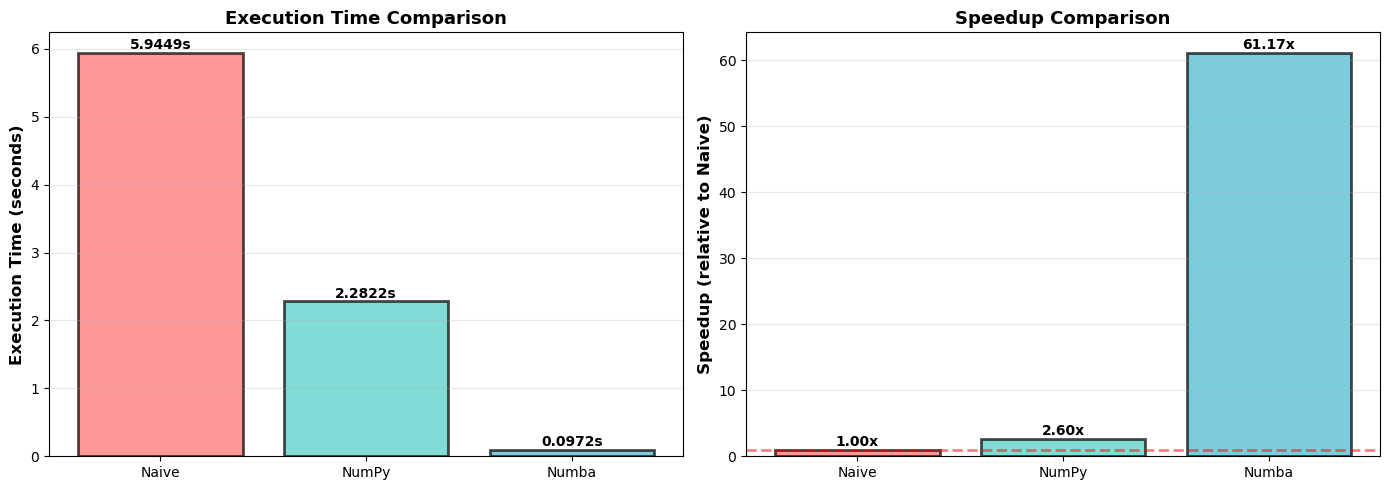

In [29]:
# Visualization of execution times
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Execution Times
implementations = ['Naive', 'NumPy', 'Numba']
times = [naive_avg, numpy_avg, numba_avg]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

ax1.bar(implementations, times, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Execution Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Execution Time Comparison', fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, (impl, time_val) in enumerate(zip(implementations, times)):
    ax1.text(i, time_val + 0.01, f'{time_val:.4f}s', ha='center', va='bottom', fontweight='bold')

# Bar chart: Speedups
speedups = [1.0, numpy_speedup, numba_speedup]
ax2.bar(implementations, speedups, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('Speedup (relative to Naive)', fontsize=12, fontweight='bold')
ax2.set_title('Speedup Comparison', fontsize=13, fontweight='bold')
ax2.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Baseline')
ax2.grid(axis='y', alpha=0.3)
for i, (impl, speedup_val) in enumerate(zip(implementations, speedups)):
    ax2.text(i, speedup_val + 0.1, f'{speedup_val:.2f}x', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Scaling Analysis

 progressively increase resolution from small (256×256) to large (2048×2048+).

In [30]:
# Define scaling test parameters
# Progress from small to large problem sizes
scaling_resolutions = [
    (256, 256),
    (512, 512),
    (1024, 1024),
    (2048, 2048),
]

# Reduced iterations for larger sizes to keep runtime manageable
scaling_max_iter = 50

# Store results for plotting
naive_scaling_times = []
naive_scaling_sizes = []
numpy_scaling_times = []
numpy_scaling_sizes = []
numba_scaling_times = []
numba_scaling_sizes = []

print("SCALING ANALYSIS: Testing with Progressively Larger Problem Sizes")
print(f"Using max_iter = {scaling_max_iter}")
print(f"Resolutions: {[f'{w}×{h}' for w, h in scaling_resolutions]}\n")

for w, h in scaling_resolutions:
    num_pixels = w * h
    print(f"RESOLUTION: {w} × {h} ({num_pixels:,} pixels)")    
    # NAIVE IMPLEMENTATION
    # Skip naive for largest size (would take too long)
    if w <= 1024:
        print(f"Testing NAIVE (Pure Python)...", end=" ", flush=True)
        try:
            start = time.perf_counter()
            _ = generate_mandelbrot_naive(w, h, scaling_max_iter)
            end = time.perf_counter()
            naive_time = end - start
            naive_scaling_times.append(naive_time)
            naive_scaling_sizes.append(num_pixels)
            print(f" {naive_time:.4f} seconds")
        except Exception as e:
            print(f" Error: {e}")
    else:
        print(f"Testing NAIVE (Pure Python)... Skipped (would take too long)")
    
    # NUMPY IMPLEMENTATION
    print(f"Testing NUMPY (Vectorized)...", end=" ", flush=True)
    try:
        start = time.perf_counter()
        _ = generate_mandelbrot_numpy(w, h, scaling_max_iter)
        end = time.perf_counter()
        numpy_time = end - start
        numpy_scaling_times.append(numpy_time)
        numpy_scaling_sizes.append(num_pixels)
        print(f" {numpy_time:.4f} seconds")
    except Exception as e:
        print(f" Error: {e}")
    
    # NUMBA IMPLEMENTATION
    print(f"Testing NUMBA (JIT)...", end=" ", flush=True)
    try:
        start = time.perf_counter()
        _ = generate_mandelbrot_numba(w, h, scaling_max_iter)
        end = time.perf_counter()
        numba_time = end - start
        numba_scaling_times.append(numba_time)
        numba_scaling_sizes.append(num_pixels)
        print(f" {numba_time:.4f} seconds")
    except Exception as e:
        print(f" Error: {e}")

print("Scaling analysis complete!\n")

SCALING ANALYSIS: Testing with Progressively Larger Problem Sizes
Using max_iter = 50
Resolutions: ['256×256', '512×512', '1024×1024', '2048×2048']

RESOLUTION: 256 × 256 (65,536 pixels)
Testing NAIVE (Pure Python)...  0.2299 seconds
Testing NUMPY (Vectorized)...  0.0391 seconds
Testing NUMBA (JIT)...  0.0043 seconds
RESOLUTION: 512 × 512 (262,144 pixels)
Testing NAIVE (Pure Python)...  0.9280 seconds
Testing NUMPY (Vectorized)...  0.2394 seconds
Testing NUMBA (JIT)...  0.0132 seconds
RESOLUTION: 1024 × 1024 (1,048,576 pixels)
Testing NAIVE (Pure Python)...  3.7476 seconds
Testing NUMPY (Vectorized)...  1.2618 seconds
Testing NUMBA (JIT)...  0.0564 seconds
RESOLUTION: 2048 × 2048 (4,194,304 pixels)
Testing NAIVE (Pure Python)... Skipped (would take too long)
Testing NUMPY (Vectorized)...  5.0376 seconds
Testing NUMBA (JIT)...  0.2254 seconds
Scaling analysis complete!



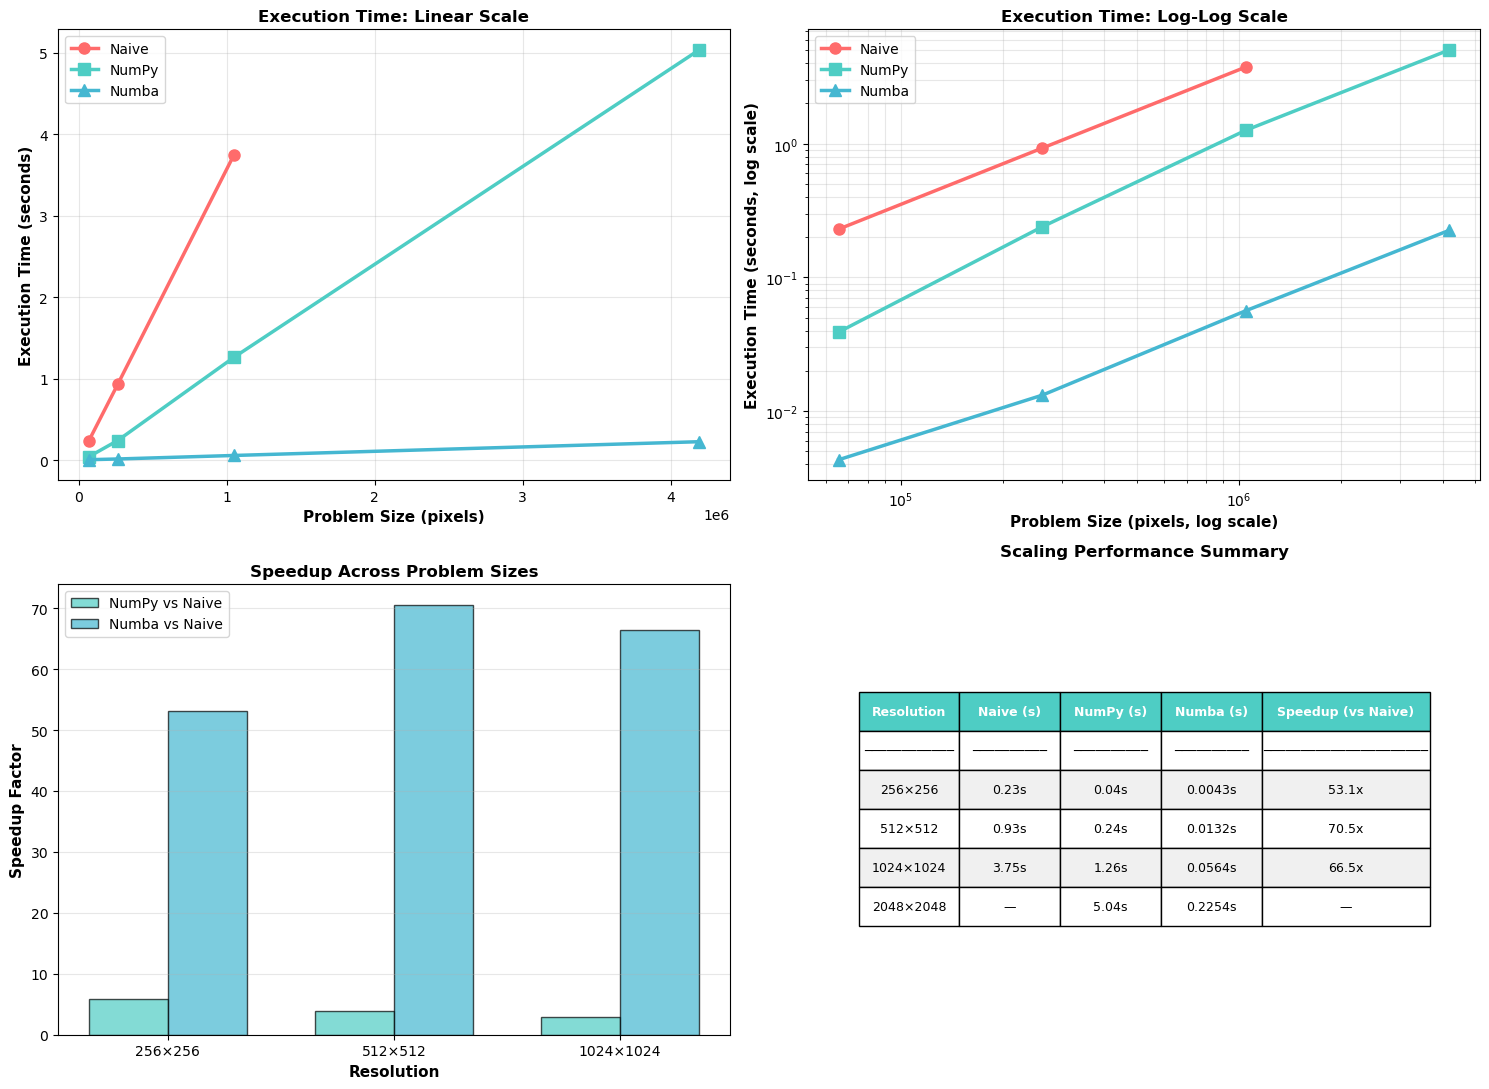

In [31]:
# Visualize scaling behavior
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Convert pixel counts to resolution labels for readability
resolution_labels = [f'{w}×{h}' for w, h in scaling_resolutions[:len(numpy_scaling_sizes)]]

# PLOT 1: Execution Time vs Problem Size (Linear Scale)
ax = axes[0, 0]
if naive_scaling_times:
    ax.plot(naive_scaling_sizes, naive_scaling_times, 'o-', linewidth=2.5, 
            markersize=8, label='Naive', color='#FF6B6B')
ax.plot(numpy_scaling_sizes, numpy_scaling_times, 's-', linewidth=2.5, 
        markersize=8, label='NumPy', color='#4ECDC4')
ax.plot(numba_scaling_sizes, numba_scaling_times, '^-', linewidth=2.5, 
        markersize=8, label='Numba', color='#45B7D1')
ax.set_xlabel('Problem Size (pixels)', fontsize=11, fontweight='bold')
ax.set_ylabel('Execution Time (seconds)', fontsize=11, fontweight='bold')
ax.set_title('Execution Time: Linear Scale', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# PLOT 2: Execution Time vs Problem Size (Log-Log Scale)
ax = axes[0, 1]
if naive_scaling_times:
    ax.loglog(naive_scaling_sizes, naive_scaling_times, 'o-', linewidth=2.5, 
              markersize=8, label='Naive', color='#FF6B6B')
ax.loglog(numpy_scaling_sizes, numpy_scaling_times, 's-', linewidth=2.5, 
          markersize=8, label='NumPy', color='#4ECDC4')
ax.loglog(numba_scaling_sizes, numba_scaling_times, '^-', linewidth=2.5, 
          markersize=8, label='Numba', color='#45B7D1')
ax.set_xlabel('Problem Size (pixels, log scale)', fontsize=11, fontweight='bold')
ax.set_ylabel('Execution Time (seconds, log scale)', fontsize=11, fontweight='bold')
ax.set_title('Execution Time: Log-Log Scale', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

# PLOT 3: Speedup Factors at Each Size
ax = axes[1, 0]
# Calculate speedups at each matching resolution
speedups_numpy_at_sizes = []
speedups_numba_at_sizes = []
matching_sizes = []

if naive_scaling_times:
    for i in range(len(naive_scaling_times)):
        naive_t = naive_scaling_times[i]
        numpy_t = numpy_scaling_times[i]
        numba_t = numba_scaling_times[i]
        speedups_numpy_at_sizes.append(naive_t / numpy_t)
        speedups_numba_at_sizes.append(naive_t / numba_t)
        matching_sizes.append(i)
    
    labels = [resolution_labels[i] for i in matching_sizes]
    x = range(len(labels))
    width = 0.35
    
    ax.bar([xi - width/2 for xi in x], speedups_numpy_at_sizes, width, 
           label='NumPy vs Naive', color='#4ECDC4', alpha=0.7, edgecolor='black')
    ax.bar([xi + width/2 for xi in x], speedups_numba_at_sizes, width, 
           label='Numba vs Naive', color='#45B7D1', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Resolution', fontsize=11, fontweight='bold')
    ax.set_ylabel('Speedup Factor', fontsize=11, fontweight='bold')
    ax.set_title('Speedup Across Problem Sizes', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

# PLOT 4: Scaling Summary Table
ax = axes[1, 1]
ax.axis('off')

# Create summary table
table_data = []
table_data.append(['Resolution', 'Naive (s)', 'NumPy (s)', 'Numba (s)', 'Speedup (vs Naive)'])
table_data.append(['─' * 12, '─' * 10, '─' * 10, '─' * 10, '─' * 22])

for i in range(len(numpy_scaling_sizes)):
    res_label = f"{scaling_resolutions[i][0]}×{scaling_resolutions[i][1]}"
    
    # Get times
    naive_str = f"{naive_scaling_times[i]:.2f}s" if i < len(naive_scaling_times) else "—"
    numpy_str = f"{numpy_scaling_times[i]:.2f}s"
    numba_str = f"{numba_scaling_times[i]:.4f}s"
    
    # Calculate speedup
    if i < len(naive_scaling_times):
        speedup_str = f"{naive_scaling_times[i] / numba_scaling_times[i]:.1f}x"
    else:
        speedup_str = "—"
    
    table_data.append([res_label, naive_str, numpy_str, numba_str, speedup_str])

# Add table to plot
table = ax.table(cellText=table_data, cellLoc='center', loc='center',
                colWidths=[0.15, 0.15, 0.15, 0.15, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(2, len(table_data)):
    for j in range(5):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#F0F0F0')
        else:
            table[(i, j)].set_facecolor('#FFFFFF')

ax.set_title('Scaling Performance Summary', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [32]:
# Analyze scaling behavior: compute scaling exponents
import math

print("SCALING BEHAVIOR ANALYSIS")

def compute_scaling_exponent(sizes, times):
    """
    Fit log(time) = exponent * log(size) + constant
    A quadratic relationship (one iteration per pixel) should have exponent ≈ 2
    """
    if len(sizes) < 2:
        return None
    
    log_sizes = [math.log(s) for s in sizes]
    log_times = [math.log(t) for t in times]
    
    # Linear regression
    n = len(log_sizes)
    sum_x = sum(log_sizes)
    sum_y = sum(log_times)
    sum_xx = sum(x**2 for x in log_sizes)
    sum_xy = sum(x*y for x, y in zip(log_sizes, log_times))
    
    denominator = n * sum_xx - sum_x**2
    if denominator == 0:
        return None
    
    exponent = (n * sum_xy - sum_x * sum_y) / denominator
    return exponent

print("\nScaling Exponents (from log-log analysis):")
print("* Exponent ~ 2.0 indicates O(n²) behavior (quadratic scaling)")
print("* Each doubling of linear size - 4x execution time")
print()

if naive_scaling_times:
    naive_exp = compute_scaling_exponent(naive_scaling_sizes, naive_scaling_times)
    if naive_exp:
        print(f"Naive Implementation:   {naive_exp:.3f} (O(n^{naive_exp:.2f}))")

numpy_exp = compute_scaling_exponent(numpy_scaling_sizes, numpy_scaling_times)
if numpy_exp:
    print(f"NumPy Implementation:   {numpy_exp:.3f} (O(n^{numpy_exp:.2f}))")

numba_exp = compute_scaling_exponent(numba_scaling_sizes, numba_scaling_times)
if numba_exp:
    print(f"Numba Implementation:   {numba_exp:.3f} (O(n^{numba_exp:.2f}))")


SCALING BEHAVIOR ANALYSIS

Scaling Exponents (from log-log analysis):
* Exponent ~ 2.0 indicates O(n²) behavior (quadratic scaling)
* Each doubling of linear size - 4x execution time

Naive Implementation:   1.007 (O(n^1.01))
NumPy Implementation:   1.172 (O(n^1.17))
Numba Implementation:   0.960 (O(n^0.96))


In [33]:
# Estimate execution times for larger sizes using scaling exponent
print("EXTRAPOLATION: Estimated Times for Larger Problem Sizes")

if naive_scaling_times and naive_exp:
    # Use the largest naive measurement as reference
    largest_naive_size = naive_scaling_sizes[-1]
    largest_naive_time = naive_scaling_times[-1]
    
    print(f"\nNaive Implementation Estimates (based on O(n^{naive_exp:.2f}) scaling):")
    print(f"Reference point: {int(math.sqrt(largest_naive_size))}×{int(math.sqrt(largest_naive_size))} = {largest_naive_time:.2f}s\n")
    
    test_sizes = [1536*1536, 2048*2048, 3072*3072, 4096*4096]
    test_labels = ["1536×1536", "2048×2048", "3072×3072", "4096×4096"]
    
    for size, label in zip(test_sizes, test_labels):
        # Extrapolate using power law
        ratio = size / largest_naive_size
        scaling = ratio ** (naive_exp / 2.0)  # Divide by 2 because we're relating pixel count to linear dim
        estimated_time = largest_naive_time * scaling
        
        # Convert to readable format
        if estimated_time < 60:
            time_str = f"{estimated_time:.1f} seconds"
        elif estimated_time < 3600:
            time_str = f"{estimated_time/60:.1f} minutes"
        else:
            time_str = f"{estimated_time/3600:.1f} hours"
        
        print(f"  {label:12}  -  ~{time_str:>12}  ({scaling:.1f}x slower than {int(math.sqrt(largest_naive_size))}×{int(math.sqrt(largest_naive_size))})")

# Compare Numba's performance at largest tested size
if numba_scaling_times:
    largest_numba_time = numba_scaling_times[-1]
    largest_size_label = f"{scaling_resolutions[len(numba_scaling_sizes)-1][0]}×{scaling_resolutions[len(numba_scaling_sizes)-1][1]}"
    
    print(f"\nNumba Implementation Performance (actual measurement):")
    print(f"  {largest_size_label:12}  -  {largest_numba_time:.4f} seconds  (nearly instant)")
    
    if naive_scaling_times:
        speedup_at_largest = naive_scaling_times[-1] / largest_numba_time
        print(f"\n  Speedup: Numba is {speedup_at_largest:.0f}x faster than Naive at {largest_size_label}")


EXTRAPOLATION: Estimated Times for Larger Problem Sizes

Naive Implementation Estimates (based on O(n^1.01) scaling):
Reference point: 1024×1024 = 3.75s

  1536×1536     -  ~ 5.6 seconds  (1.5x slower than 1024×1024)
  2048×2048     -  ~ 7.5 seconds  (2.0x slower than 1024×1024)
  3072×3072     -  ~11.3 seconds  (3.0x slower than 1024×1024)
  4096×4096     -  ~15.1 seconds  (4.0x slower than 1024×1024)

Numba Implementation Performance (actual measurement):
  2048×2048     -  0.2254 seconds  (nearly instant)

  Speedup: Numba is 17x faster than Naive at 2048×2048
